In [1]:
import numpy as np
from sklearn.cluster import KMeans

dataset = np.load('./mnist.npz')
print(dataset)

NpzFile './mnist.npz' with keys: X_train, y_train, X_test, y_test


In [2]:
X_train, y_train = dataset['X_train'], dataset['y_train']
X_test, y_test = dataset['X_test'], dataset['y_test']
print(X_train.shape, y_train.shape)
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)
y_test = np.argmax(y_test, axis=1)


(60000, 28, 28) (60000, 10)


In [3]:
num_clusters = 30
Je_ls = []
for n in range(1, num_clusters + 1):
    kmeans = KMeans(n_clusters=n, random_state=1234)
    kmeans.fit(X_train)
    Je_ls.append(kmeans.inertia_)

    del kmeans

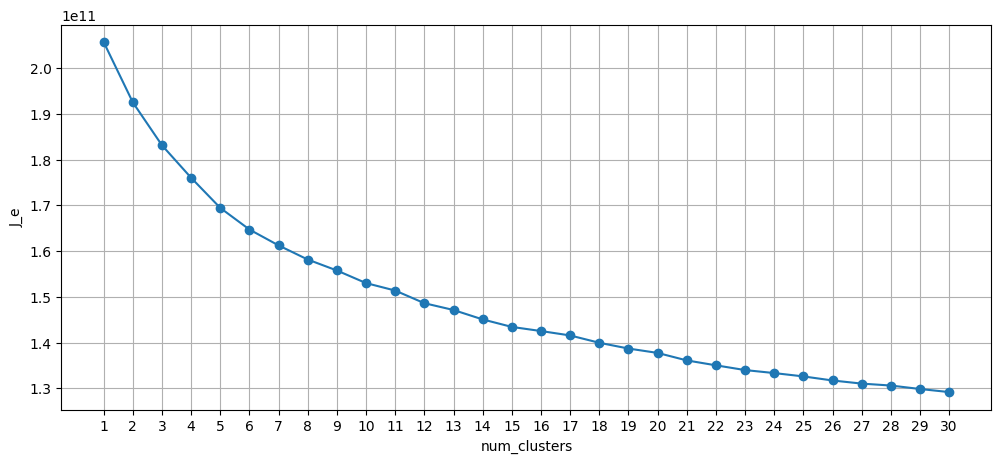

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.plot(range(1, len(Je_ls) + 1), Je_ls, marker='o', linestyle='-')
plt.xlabel('num_clusters')
plt.ylabel('J_e')
plt.xticks(range(1, num_clusters+1))
plt.grid(True)
plt.show()

In [5]:
kmeans = KMeans(n_clusters=10, n_init='auto', random_state=1234)
kmeans.fit(X_train)

from PIL import Image

centers = kmeans.cluster_centers_
imgs = []
for center in centers:
    center = center.reshape(28, 28)
    img = Image.fromarray(center)
    imgs.append(img)

con_img = Image.new('L', (10 * 28, 28))
for idx, img in enumerate(imgs):
    x = idx * 28
    con_img.paste(img, (x, 0))

con_img.show()

In [6]:
labels = np.zeros(10, dtype=int)
for k in range(10):
    cluster_mems = y_train[kmeans.labels_ == k]
    counts = cluster_mems.sum(axis=0)
    labels[k] = np.argmax(counts)

print(labels)

[2 3 9 1 0 4 6 8 7 1]


In [7]:
pred_y = kmeans.predict(X_test)
pred_y = labels[pred_y]
acc = (pred_y == y_test).mean()
print(acc)

0.586


In [ ]:
from sklearn.mixture import GaussianMixture

kmeans = GaussianMixture(
    n_components=10,
    covariance_type='diag',
    # full counts for more than 5 mins, too slow
    # and full_acc = 0.40+, little diff from diag
    init_params='k-means++',
    random_state=1234).fit(X_train)

In [13]:
centers = kmeans.means_
imgs = []
for center in centers:
    center = center.reshape(28, 28)
    img = Image.fromarray(center.astype(np.uint8))
    imgs.append(img)

con_img = Image.new('L', (10 * 28, 28))
for idx, img in enumerate(imgs):
    x = idx * 28
    con_img.paste(img, (x, 0))

con_img.show()

In [14]:
labels = np.zeros(10, dtype=int)
pred_label = kmeans.predict(X_train.astype(np.float32))
for k in range(10):
    cluster_mems = y_train[pred_label == k]
    counts = cluster_mems.sum(axis=0)
    labels[k] = np.argmax(counts)

print(labels)
pred_y = kmeans.predict(X_test.astype(np.float32))
pred_y = labels[pred_y]
acc = (pred_y == y_test).mean()
print(acc)

[2 3 6 1 0 7 6 5 9 7]
0.3914
